<a href="https://colab.research.google.com/github/Valentine250/-Project-Easy-Visa/blob/main/Anova_Insurance_ML_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Anova Insurance — Health Classification ML Model

**Objective:** Predict whether an individual is `Healthy (0)` or `Unhealthy (1)` using health data, to assist Anova Insurance in determining eligibility and premium pricing.

---
### Notebook Structure
1. Install & Import Libraries
2. Load & Inspect Data
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing & Feature Engineering
5. Train/Test Split
6. Model Training (Logistic Regression, Random Forest, XGBoost)
7. Model Evaluation & Comparison
8. Feature Importance
9. Final Prediction Pipeline
10. Conclusions & Recommendations


## 1️⃣ Install & Import Libraries

In [1]:
# Install any missing packages (XGBoost is usually pre-installed in Colab)
!pip install xgboost --quiet

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Sklearn — models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# XGBoost
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay, f1_score
)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 2️⃣ Load & Inspect Data

> **Upload the file** `Healthcare_Data_Preprocessed_FIXED.csv` when prompted below.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving iOnFZ4UzSm2logfWqmyf_Healthcare_Data_Preprocessed_FIXED.csv to iOnFZ4UzSm2logfWqmyf_Healthcare_Data_Preprocessed_FIXED.csv


In [4]:
# Read the uploaded file (grab whichever CSV was uploaded)
filename = [f for f in uploaded.keys() if f.endswith('.csv')][0]
df = pd.read_csv(filename)

print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
df.head()

Dataset shape: (10000, 23)
Rows: 10,000  |  Columns: 23


,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type_Vegan,Diet_Type_Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,37.00,26.00,111.00,198.00,99.00,72.00,5.50,1.70,1.60,4.40,1,2,2,1,2,1,0.00,1.00,False,True,True,False,False
1,37.00,24.00,121.00,199.00,103.00,75.00,4.50,1.90,2.60,5.60,1,0,1,1,2,1,2.00,2.00,False,False,True,False,False
2,81.00,27.00,NaN,NaN,100.00,74.00,12.10,2.90,2.60,1.80,0,2,1,2,0,0,1.00,0.00,True,False,False,False,False
3,25.00,21.00,150.00,199.00,102.00,70.00,4.30,1.00,1.70,5.20,0,2,0,1,2,1,2.00,0.00,True,False,False,True,False
4,24.00,26.00,146.00,202.00,99.00,76.00,16.00,5.00,3.40,1.40,0,0,1,2,0,2,0.00,2.00,False,True,False,True,False


In [5]:
# Data types and null counts
print('=== DATA TYPES & NULL COUNTS ===')
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_%': (df.isnull().sum() / len(df) * 100).round(2),
    'unique_vals': df.nunique()
})
print(info_df)


=== DATA TYPES & NULL COUNTS ===
                        dtype  null_count  null_%  unique_vals
Age                   float64           0    0.00          101
BMI                   float64           0    0.00           14
Blood_Pressure        float64         529    5.29          175
Cholesterol           float64         538    5.38           16
Glucose_Level         float64         514    5.14           15
Heart_Rate            float64           0    0.00           14
Sleep_Hours           float64           0    0.00          161
Exercise_Hours        float64           0    0.00           51
Water_Intake          float64           0    0.00           40
Stress_Level          float64           0    0.00           96
Target                  int64           0    0.00            2
Smoking                 int64           0    0.00            3
Alcohol                 int64           0    0.00            3
Diet                    int64           0    0.00            3
MentalHealth          

In [6]:
# Statistical summary
print('=== STATISTICAL SUMMARY ===')
df.describe()

=== STATISTICAL SUMMARY ===


,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies
count,10000.00,10000.00,9471.00,9462.00,9486.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,9465.00,9479.00
mean,40.23,25.71,130.92,199.19,100.15,73.53,8.01,2.43,2.48,4.51,0.50,0.99,0.99,1.01,1.00,1.00,1.00,1.00
std,24.35,1.94,27.81,2.08,2.21,1.72,4.21,1.33,0.63,1.82,0.50,0.82,0.82,0.82,0.82,0.81,0.81,0.82
min,0.00,19.00,22.00,192.00,93.00,67.00,0.00,0.00,0.60,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,25.00,24.00,114.00,198.00,99.00,72.00,5.00,1.50,2.00,3.30,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,37.00,26.00,135.00,199.00,100.00,74.00,6.30,2.00,2.40,4.80,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
75%,49.00,27.00,150.00,200.00,102.00,75.00,10.80,3.30,2.90,5.80,1.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00
max,100.00,32.00,225.00,207.00,107.00,80.00,16.00,5.00,4.60,10.00,1.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00


=== TARGET DISTRIBUTION ===
        Count  Percentage
Target                   
0        5001       50.01
1        4999       49.99


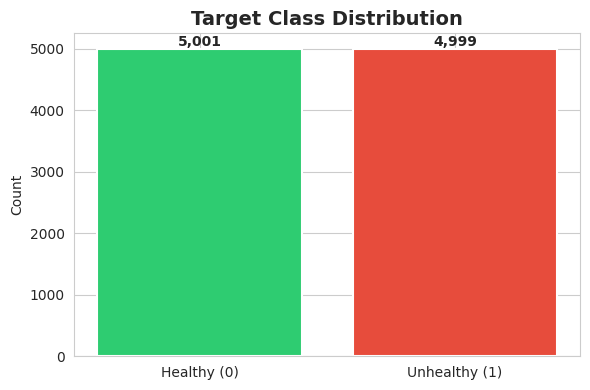

In [7]:
# Target class distribution
print('=== TARGET DISTRIBUTION ===')
target_counts = df['Target'].value_counts()
target_pct = df['Target'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': target_counts, 'Percentage': target_pct.round(2)}))

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(['Healthy (0)', 'Unhealthy (1)'], target_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, target_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'{count:,}', ha='center', fontweight='bold')
ax.set_title('Target Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 3️⃣ Exploratory Data Analysis (EDA)

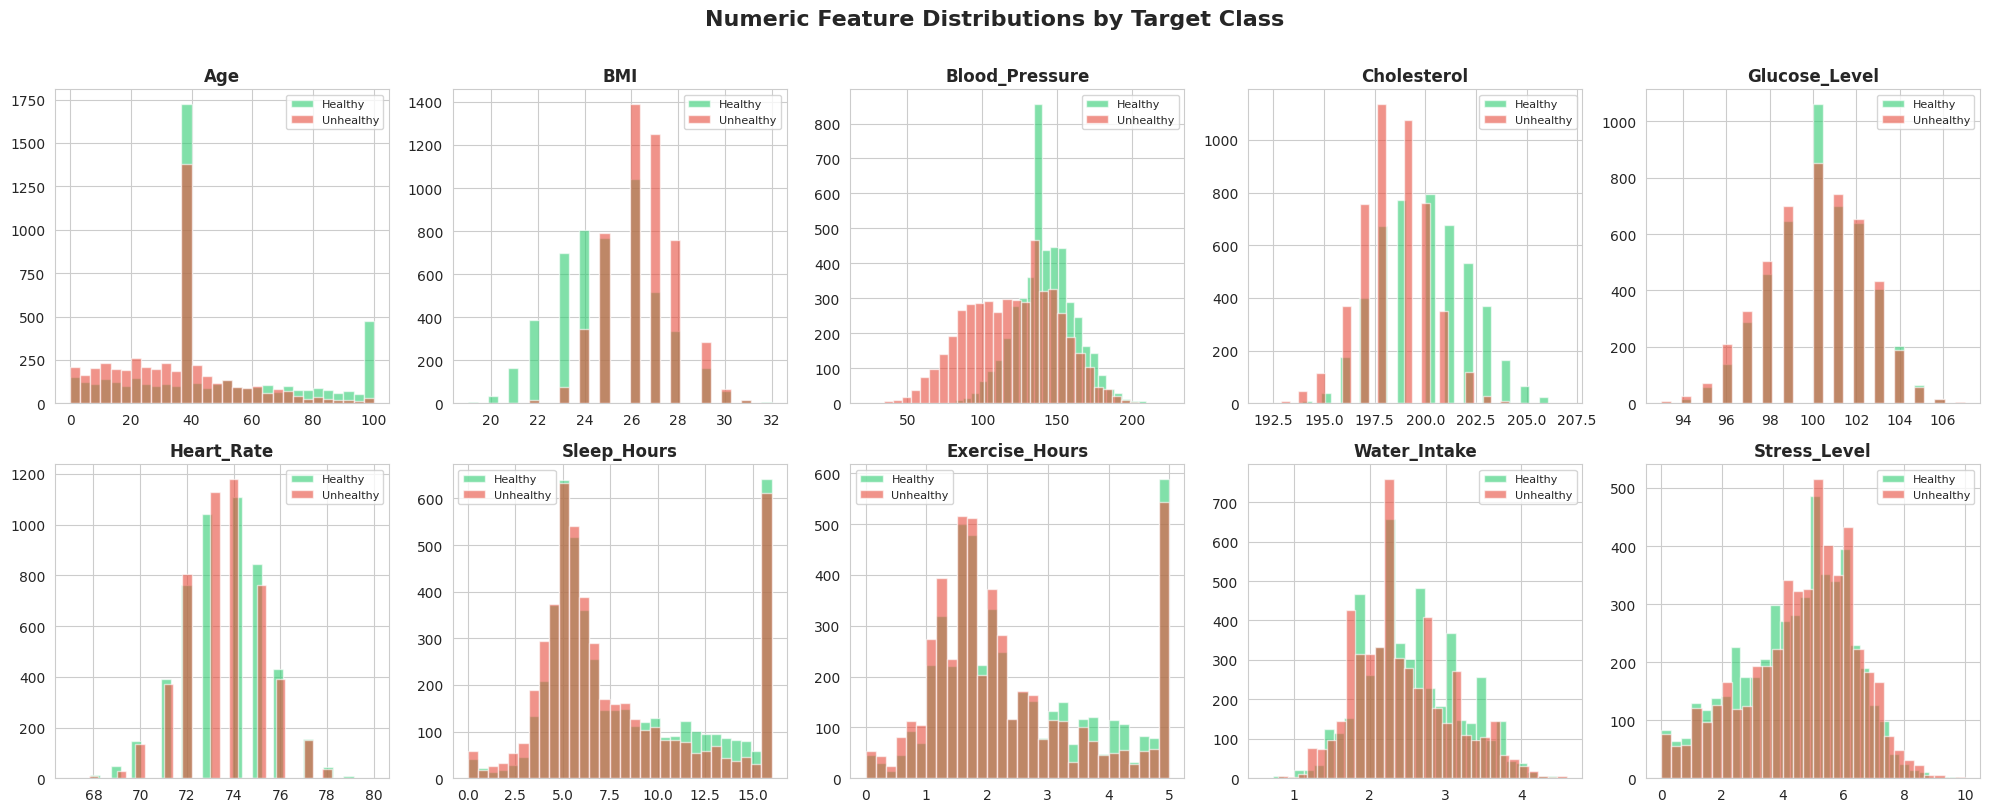

In [8]:
# Numeric columns
num_cols = ['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Glucose_Level',
            'Heart_Rate', 'Sleep_Hours', 'Exercise_Hours', 'Water_Intake', 'Stress_Level']

# Distribution plots
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
        subset = df[df['Target'] == label][col].dropna()
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label='Healthy' if label==0 else 'Unhealthy')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Numeric Feature Distributions by Target Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

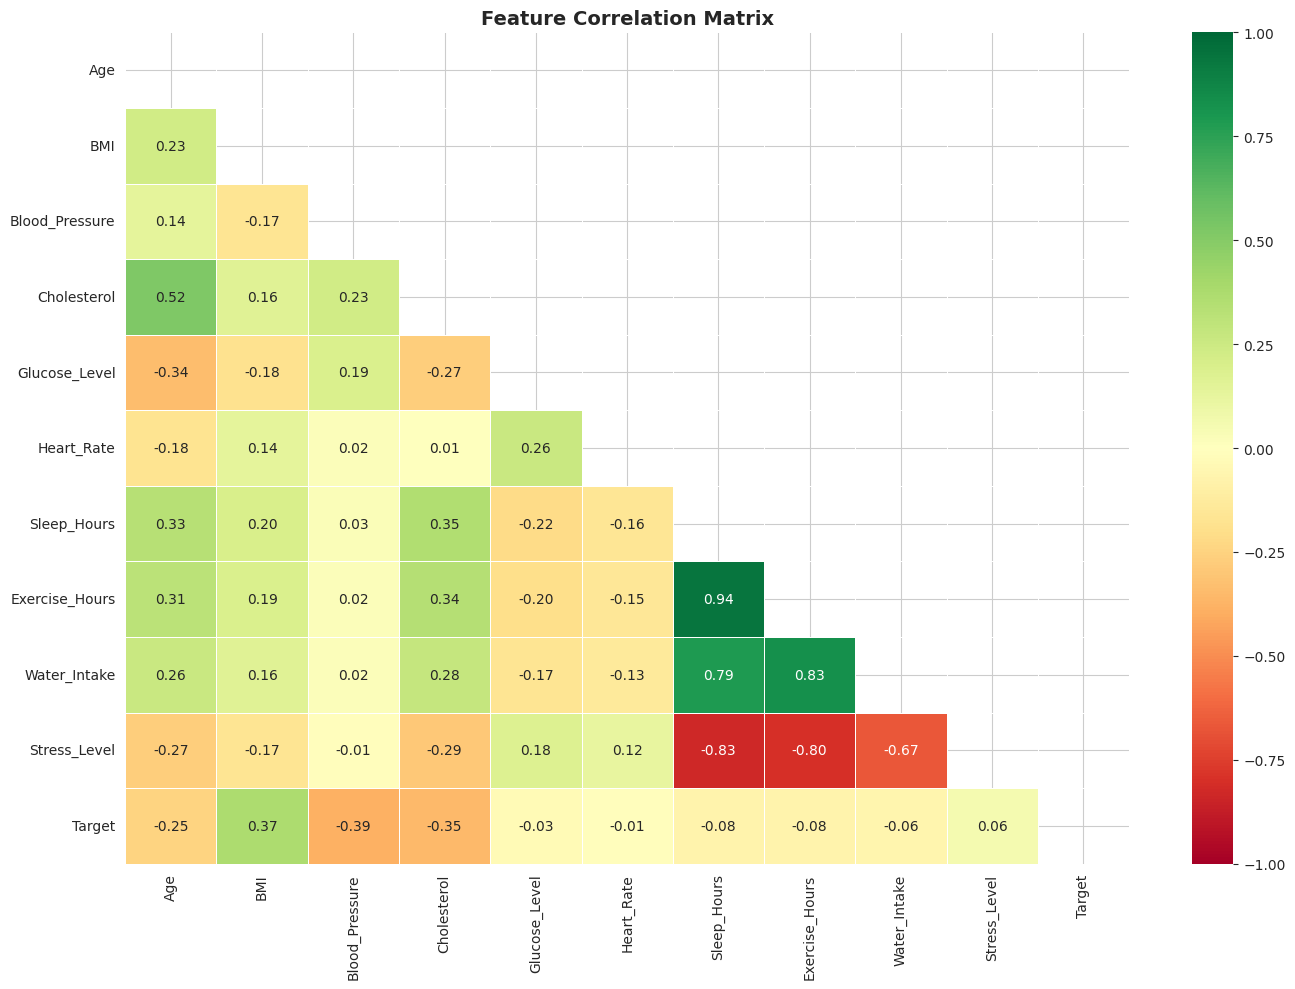

In [9]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df[num_cols + ['Target']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

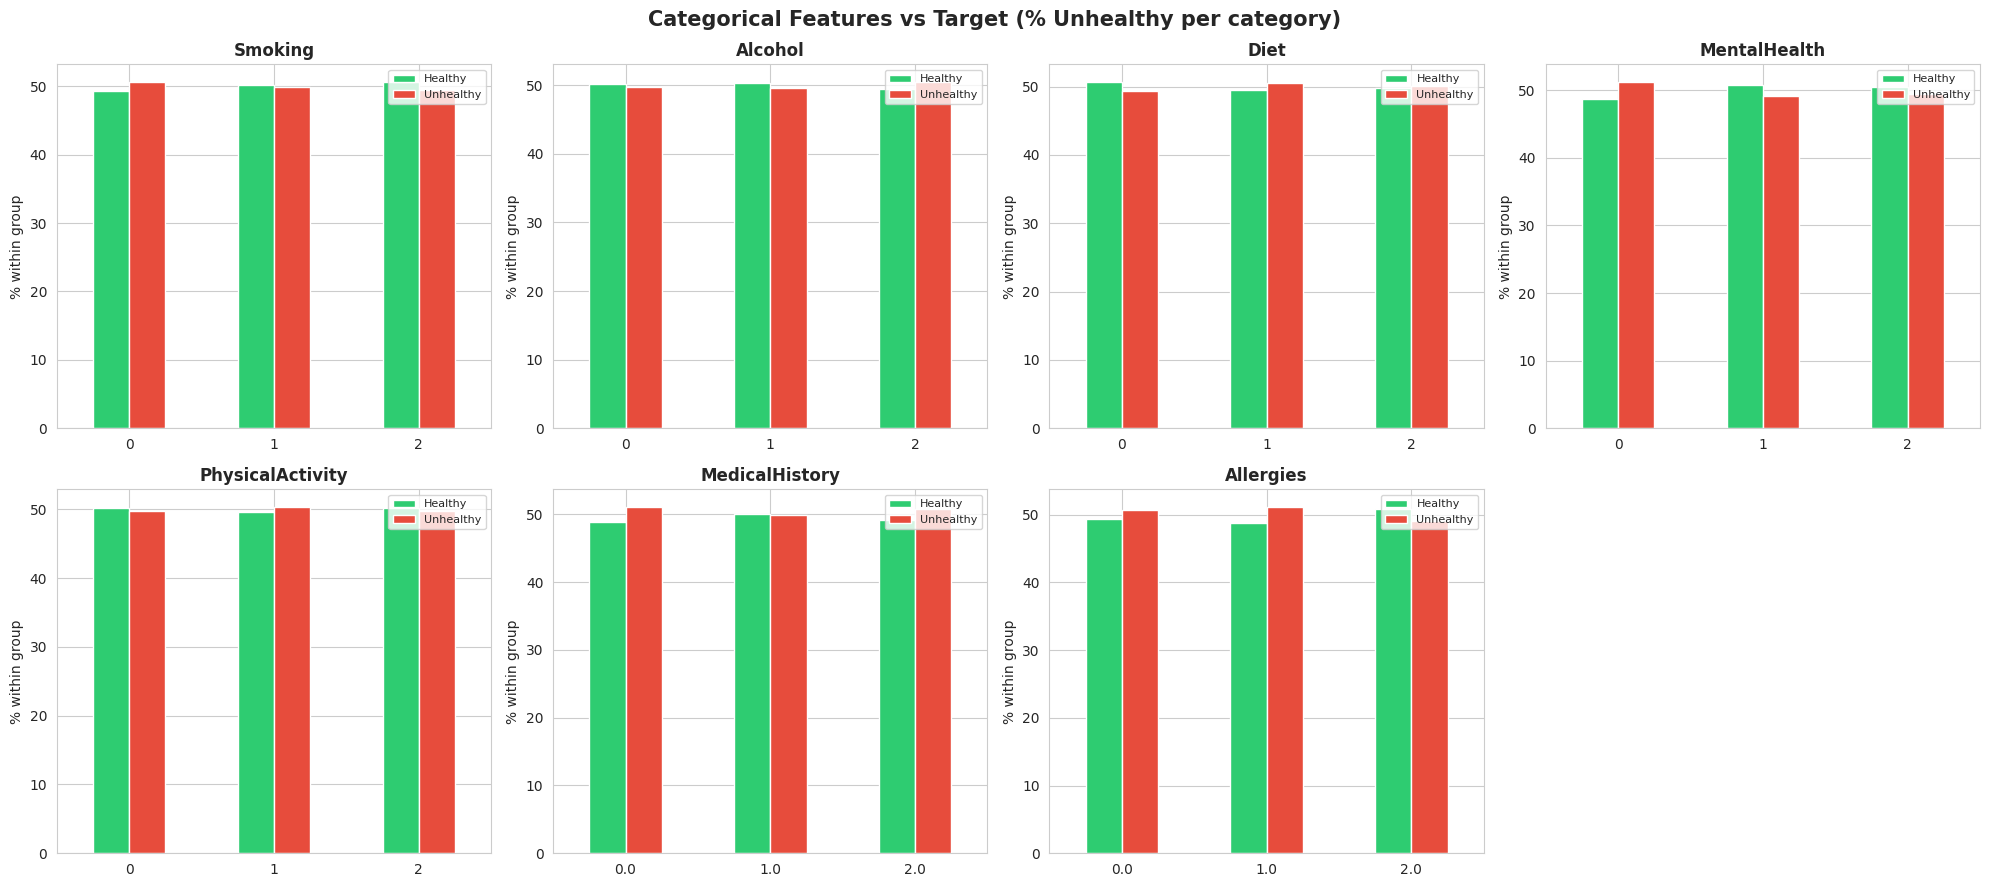

In [10]:
# Categorical features vs Target
cat_cols = ['Smoking', 'Alcohol', 'Diet', 'MentalHealth', 'PhysicalActivity', 'MedicalHistory', 'Allergies']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Target'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'], edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% within group')
    axes[i].legend(['Healthy', 'Unhealthy'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=0)

# Hide the unused last subplot
axes[-1].set_visible(False)
plt.suptitle('Categorical Features vs Target (% Unhealthy per category)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Check for negative Age values (data quality issue mentioned in problem statement)
print(f'Negative Age values: {(df["Age"] < 0).sum()}')
print(f'Age < 0 sample:\n{df[df["Age"] < 0]["Age"].head()}')
print(f'\nBMI out of range (< 10 or > 60): {((df["BMI"] < 10) | (df["BMI"] > 60)).sum()}')
print(f'Blood Pressure extremes (< 60 or > 200): {((df["Blood_Pressure"] < 60) | (df["Blood_Pressure"] > 200)).sum()}')

Negative Age values: 0
Age < 0 sample:
Series([], Name: Age, dtype: float64)

BMI out of range (< 10 or > 60): 0
Blood Pressure extremes (< 60 or > 200): 107


## 4️⃣ Data Preprocessing & Feature Engineering

In [12]:
# Work on a copy
df_clean = df.copy()

# --- Fix negative Age values (treat as data entry error → take absolute value) ---
df_clean['Age'] = df_clean['Age'].abs()
print(f'After fixing: Negative Age values remaining: {(df_clean["Age"] < 0).sum()}')

# --- Handle missing values ---
# Numeric columns: impute with median (robust to outliers)
num_cols_all = ['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Glucose_Level',
                'Heart_Rate', 'Sleep_Hours', 'Exercise_Hours', 'Water_Intake',
                'Stress_Level', 'MedicalHistory', 'Allergies']

for col in num_cols_all:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'  Imputed {col} with median = {median_val:.2f}')

print(f'\nRemaining nulls: {df_clean.isnull().sum().sum()}')
print('✅ Missing values handled!')

After fixing: Negative Age values remaining: 0
  Imputed Blood_Pressure with median = 135.00
  Imputed Cholesterol with median = 199.00
  Imputed Glucose_Level with median = 100.00
  Imputed MedicalHistory with median = 1.00
  Imputed Allergies with median = 1.00

Remaining nulls: 0
✅ Missing values handled!


In [14]:
# --- Feature Engineering ---

# BMI category (clinically meaningful)
def bmi_category(bmi):
    if bmi < 18.5: return 0   # Underweight
    elif bmi < 25: return 1   # Normal
    elif bmi < 30: return 2   # Overweight
    else: return 3            # Obese

df_clean['BMI_Category'] = df_clean['BMI'].apply(bmi_category)

# Age group
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=[0, 30, 45, 60, 100], labels=[0, 1, 2, 3], include_lowest=True).astype(int)

# High blood pressure flag (systolic > 140)
df_clean['High_BP'] = (df_clean['Blood_Pressure'] > 140).astype(int)

# Lifestyle risk score (composite)
df_clean['Lifestyle_Risk'] = (
    df_clean['Smoking'] +
    df_clean['Alcohol'] +
    df_clean['MentalHealth'] +
    (2 - df_clean['PhysicalActivity']) +  # inverse: less activity = higher risk
    (2 - df_clean['Diet'])                 # inverse: worse diet = higher risk
)

# Sleep adequacy (< 6 hours = inadequate)
df_clean['Inadequate_Sleep'] = (df_clean['Sleep_Hours'] < 6).astype(int)

print('✅ Feature engineering complete!')
print('New features:', ['BMI_Category', 'Age_Group', 'High_BP', 'Lifestyle_Risk', 'Inadequate_Sleep'])
df_clean.head(3)

✅ Feature engineering complete!
New features: ['BMI_Category', 'Age_Group', 'High_BP', 'Lifestyle_Risk', 'Inadequate_Sleep']


,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type_Vegan,Diet_Type_Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O,BMI_Category,Age_Group,High_BP,Lifestyle_Risk,Inadequate_Sleep
0,37.00,26.00,111.00,198.00,99.00,72.00,5.50,1.70,1.60,4.40,1,2,2,1,2,1,0.00,1.00,False,True,True,False,False,2,1,0,8,1
1,37.00,24.00,121.00,199.00,103.00,75.00,4.50,1.90,2.60,5.60,1,0,1,1,2,1,2.00,2.00,False,False,True,False,False,1,1,0,5,1
2,81.00,27.00,135.00,199.00,100.00,74.00,12.10,2.90,2.60,1.80,0,2,1,2,0,0,1.00,0.00,True,False,False,False,False,2,3,0,5,0


In [15]:
# --- Prepare X and y ---
# Drop Target to create features
X = df_clean.drop(columns=['Target'])
y = df_clean['Target']

# Handle boolean columns from one-hot encoding (Diet_Type_*, Blood_Group_*)
bool_cols = X.select_dtypes(include='bool').columns.tolist()
X[bool_cols] = X[bool_cols].astype(int)

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Features: {list(X.columns)}')

Feature matrix shape: (10000, 27)
Target shape: (10000,)
Features: ['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Glucose_Level', 'Heart_Rate', 'Sleep_Hours', 'Exercise_Hours', 'Water_Intake', 'Stress_Level', 'Smoking', 'Alcohol', 'Diet', 'MentalHealth', 'PhysicalActivity', 'MedicalHistory', 'Allergies', 'Diet_Type_Vegan', 'Diet_Type_Vegetarian', 'Blood_Group_AB', 'Blood_Group_B', 'Blood_Group_O', 'BMI_Category', 'Age_Group', 'High_BP', 'Lifestyle_Risk', 'Inadequate_Sleep']


## 5️⃣ Train / Test Split

In [16]:
# Stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]:,} samples')
print(f'Test set:     {X_test.shape[0]:,} samples')
print(f'\nTrain target distribution:\n{y_train.value_counts()}')
print(f'\nTest target distribution:\n{y_test.value_counts()}')

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('\n✅ Data split and scaled!')

Training set: 8,000 samples
Test set:     2,000 samples

Train target distribution:
Target
0    4001
1    3999
Name: count, dtype: int64

Test target distribution:
Target
0    1000
1    1000
Name: count, dtype: int64

✅ Data split and scaled!


## 6️⃣ Model Training

In [17]:
# Define models
models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':          DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=5, random_state=42),
    'XGBoost':                XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                                            use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1),
    'K-Nearest Neighbors':    KNeighborsClassifier(n_neighbors=7)
}

# Results container
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Training models...\n')
for name, model in models.items():
    # Use scaled data for distance/linear models, raw for tree models
    use_scaled = name in ['Logistic Regression', 'K-Nearest Neighbors']
    Xtr = X_train_scaled if use_scaled else X_train
    Xte = X_test_scaled  if use_scaled else X_test

    # Cross-validation
    cv_scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    # Fit and predict
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    acc   = accuracy_score(y_test, y_pred)
    auc   = roc_auc_score(y_test, y_prob)
    f1    = f1_score(y_test, y_pred)

    results[name] = {
        'model': model,
        'use_scaled': use_scaled,
        'CV ROC-AUC (mean)': cv_scores.mean(),
        'CV ROC-AUC (std)':  cv_scores.std(),
        'Test Accuracy':     acc,
        'Test ROC-AUC':      auc,
        'Test F1-Score':     f1,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

    print(f'{name:<25} | CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test Acc: {acc:.4f} | AUC: {auc:.4f} | F1: {f1:.4f}')

print('\n✅ All models trained!')

Training models...

Logistic Regression       | CV AUC: 0.8728 ± 0.0073 | Test Acc: 0.7940 | AUC: 0.8838 | F1: 0.7968
Decision Tree             | CV AUC: 0.8963 ± 0.0031 | Test Acc: 0.8410 | AUC: 0.9000 | F1: 0.8405
Random Forest             | CV AUC: 0.9357 ± 0.0032 | Test Acc: 0.8635 | AUC: 0.9394 | F1: 0.8687
Gradient Boosting         | CV AUC: 0.9511 ± 0.0019 | Test Acc: 0.8870 | AUC: 0.9541 | F1: 0.8882
XGBoost                   | CV AUC: 0.9514 ± 0.0021 | Test Acc: 0.8840 | AUC: 0.9530 | F1: 0.8850
K-Nearest Neighbors       | CV AUC: 0.8617 ± 0.0060 | Test Acc: 0.8035 | AUC: 0.8689 | F1: 0.8057

✅ All models trained!


## 7️⃣ Model Evaluation & Comparison

In [18]:
# Summary table
summary = pd.DataFrame([
    {
        'Model': name,
        'CV AUC Mean': v['CV ROC-AUC (mean)'],
        'CV AUC Std': v['CV ROC-AUC (std)'],
        'Test Accuracy': v['Test Accuracy'],
        'Test AUC': v['Test ROC-AUC'],
        'Test F1': v['Test F1-Score']
    }
    for name, v in results.items()
]).sort_values('Test AUC', ascending=False).reset_index(drop=True)

print('=== MODEL COMPARISON TABLE ===')
summary

=== MODEL COMPARISON TABLE ===


,Model,CV AUC Mean,CV AUC Std,Test Accuracy,Test AUC,Test F1
0,Gradient Boosting,0.95,0.00,0.89,0.95,0.89
1,XGBoost,0.95,0.00,0.88,0.95,0.89
2,Random Forest,0.94,0.00,0.86,0.94,0.87
3,Decision Tree,0.90,0.00,0.84,0.90,0.84
4,Logistic Regression,0.87,0.01,0.79,0.88,0.80
5,K-Nearest Neighbors,0.86,0.01,0.80,0.87,0.81


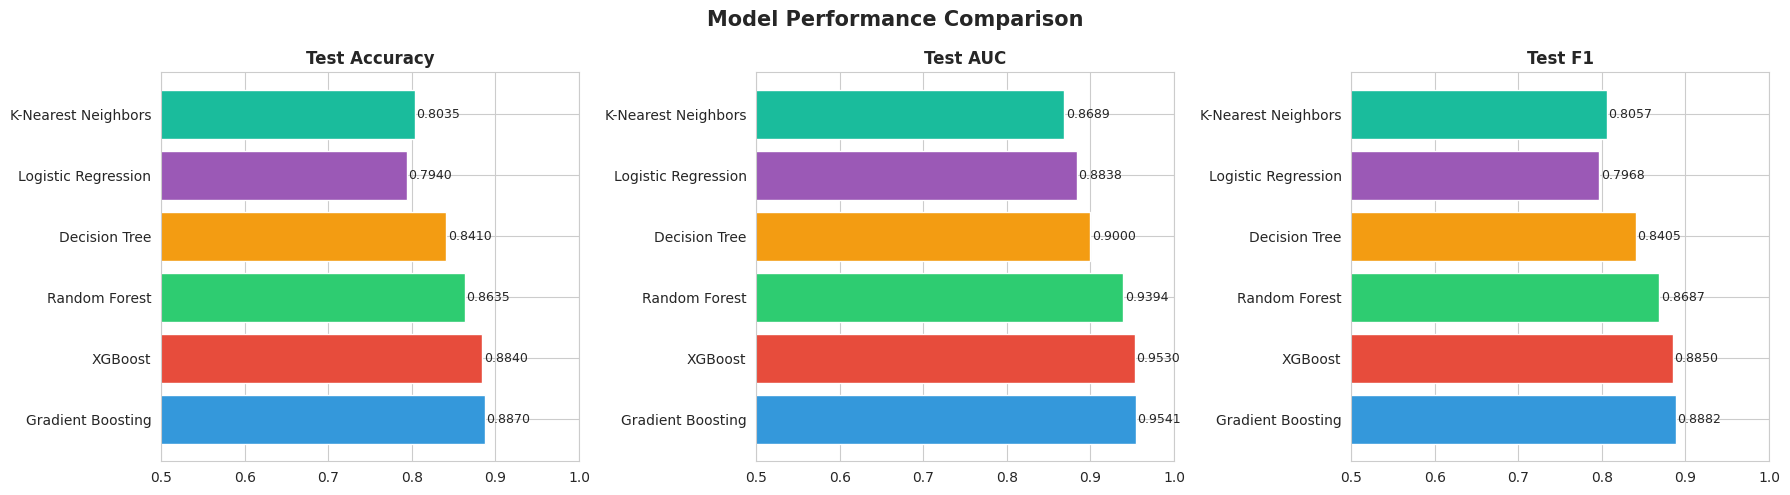

In [19]:
# Visual comparison
metrics = ['Test Accuracy', 'Test AUC', 'Test F1']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for ax, metric in zip(axes, metrics):
    vals = summary.set_index('Model')[metric]
    bars = ax.barh(vals.index, vals.values, color=colors[:len(vals)], edgecolor='white')
    ax.set_xlim(0.5, 1.0)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

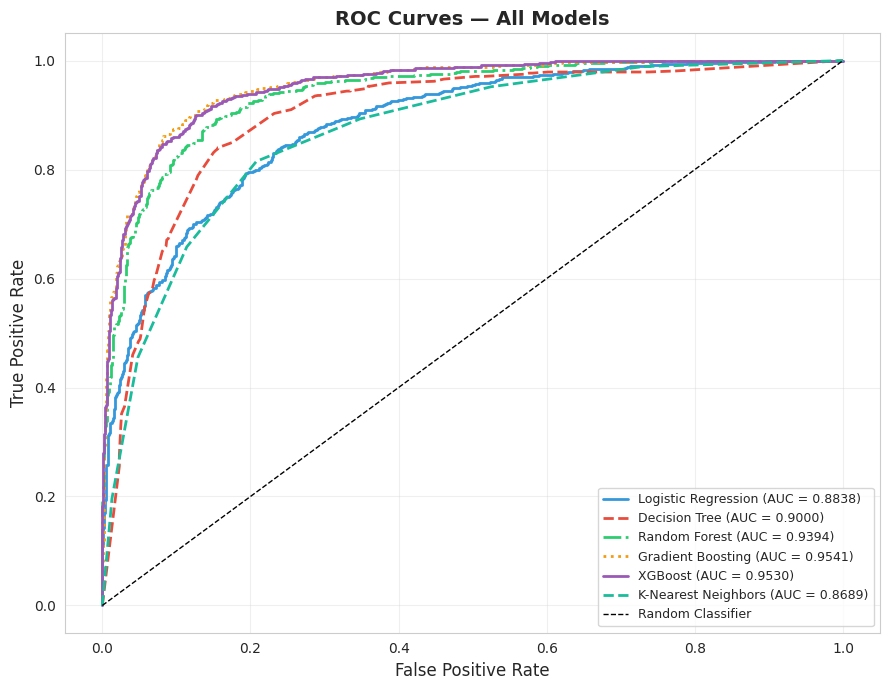

In [20]:
# ROC Curves — all models
fig, ax = plt.subplots(figsize=(9, 7))
linestyles = ['-', '--', '-.', ':', '-', '--']

for (name, v), ls, color in zip(results.items(), linestyles, colors):
    fpr, tpr, _ = roc_curve(y_test, v['y_prob'])
    ax.plot(fpr, tpr, lw=2, ls=ls, color=color,
            label=f"{name} (AUC = {v['Test ROC-AUC']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

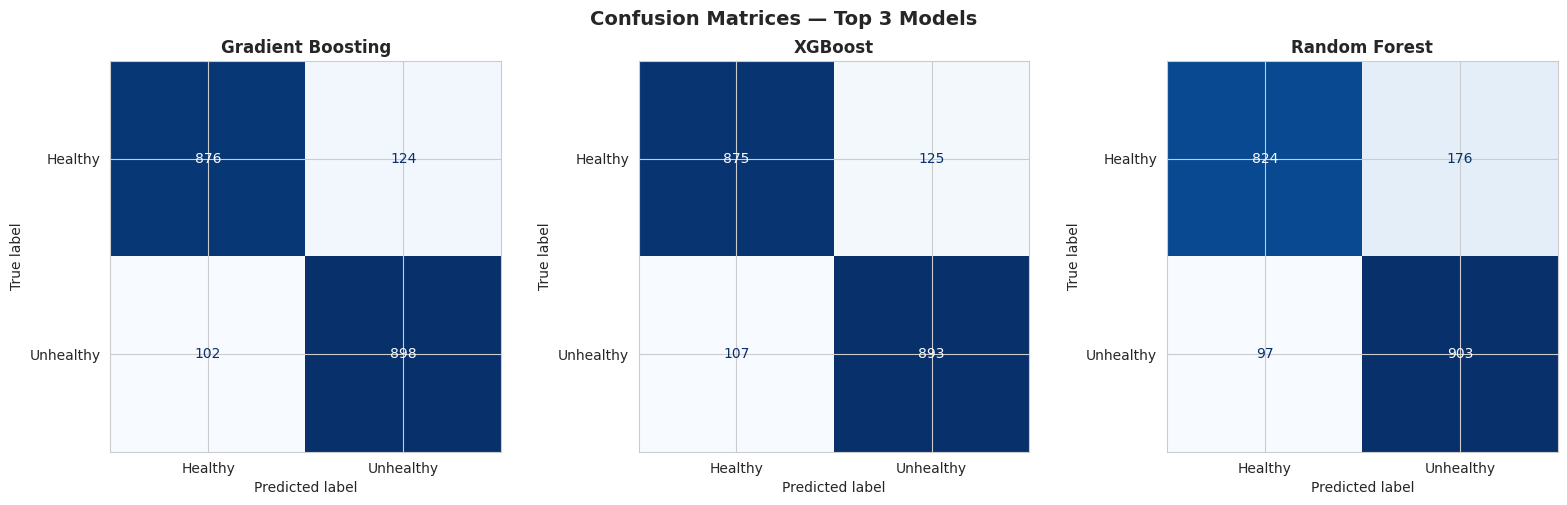

In [21]:
# Confusion matrices for top 3 models
top3 = summary.head(3)['Model'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, name in zip(axes, top3):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Unhealthy'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices — Top 3 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Detailed classification report for best model
best_model_name = summary.iloc[0]['Model']
best_y_pred     = results[best_model_name]['y_pred']

print(f'=== CLASSIFICATION REPORT: {best_model_name} (Best Model) ===')
print(classification_report(y_test, best_y_pred, target_names=['Healthy', 'Unhealthy']))

## 8️⃣ Feature Importance

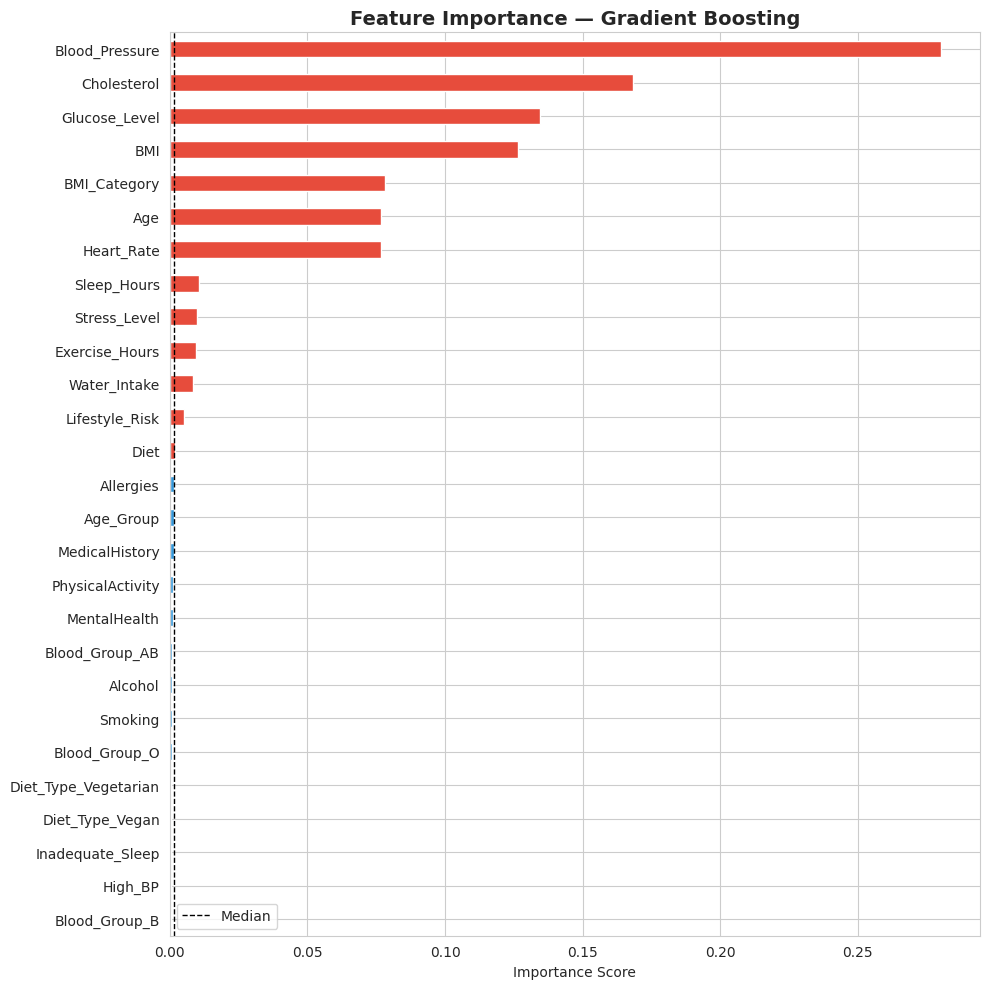

Top 10 most important features:
Blood_Pressure   0.28
Cholesterol      0.17
Glucose_Level    0.13
BMI              0.13
BMI_Category     0.08
Age              0.08
Heart_Rate       0.08
Sleep_Hours      0.01
Stress_Level     0.01
Exercise_Hours   0.01
dtype: float64


In [22]:
# Feature importance from the best tree-based model
tree_models = ['XGBoost', 'Random Forest', 'Gradient Boosting']
tree_model_name = next((m for m in summary['Model'] if m in tree_models), None)

if tree_model_name:
    model = results[tree_model_name]['model']
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 10))
    colors_imp = ['#e74c3c' if v > feat_imp.median() else '#3498db' for v in feat_imp.values]
    feat_imp.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
    ax.set_title(f'Feature Importance — {tree_model_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.axvline(feat_imp.median(), color='black', linestyle='--', lw=1, label='Median')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print('Top 10 most important features:')
    print(feat_imp.sort_values(ascending=False).head(10))

## 9️⃣ Final Prediction Pipeline

In [27]:
# Best model ready-to-use prediction function
best_model_name = summary.iloc[0]['Model'] # Define best_model_name
best_model  = results[best_model_name]['model']
use_scaled  = results[best_model_name]['use_scaled']

def predict_health_status(input_dict: dict) -> dict:
    """
    Predict health status for a new applicant.

    Parameters
    ----------
    input_dict : dict
        Dictionary with same keys as training features.

    Returns
    -------
    dict with prediction, probability, and recommendation.
    """
    row = pd.DataFrame([input_dict])

    # Apply same feature engineering
    row['BMI_Category']   = row['BMI'].apply(bmi_category)
    row['Age_Group']      = pd.cut(row['Age'], bins=[0,30,45,60,100], labels=[0,1,2,3]).astype(int)
    row['High_BP']        = (row['Blood_Pressure'] > 140).astype(int)
    row['Lifestyle_Risk'] = (row['Smoking'] + row['Alcohol'] + row['MentalHealth'] +
                             (2 - row['PhysicalActivity']) + (2 - row['Diet']))
    row['Inadequate_Sleep'] = (row['Sleep_Hours'] < 6).astype(int)

    # Ensure column order matches training
    row = row[X.columns]

    # Scale if required
    row_input = scaler.transform(row) if use_scaled else row

    pred  = best_model.predict(row_input)[0]
    prob  = best_model.predict_proba(row_input)[0][1]

    status = 'Unhealthy' if pred == 1 else 'Healthy'
    risk   = 'High Risk' if prob > 0.7 else ('Moderate Risk' if prob > 0.4 else 'Low Risk')

    return {
        'Prediction':          status,
        'Unhealthy_Probability': round(float(prob), 4),
        'Risk_Category':       risk,
        'Premium_Recommendation': (
            'Standard Premium' if pred == 0
            else ('Moderate Surcharge' if prob < 0.7 else 'High Surcharge / Further Review')
        )
    }


# ── Example usage ──
sample_applicant = {
    'Age': 45, 'BMI': 29.5, 'Blood_Pressure': 145, 'Cholesterol': 220,
    'Glucose_Level': 105, 'Heart_Rate': 85, 'Sleep_Hours': 5.0,
    'Exercise_Hours': 0.5, 'Water_Intake': 1.5, 'Stress_Level': 7,
    'Smoking': 2, 'Alcohol': 1, 'Diet': 0, 'MentalHealth': 2,
    'PhysicalActivity': 0, 'MedicalHistory': 2, 'Allergies': 1,
    'Diet_Type_Vegan': 0, 'Diet_Type_Vegetarian': 0,
    'Blood_Group_AB': 0, 'Blood_Group_B': 0, 'Blood_Group_O': 1
}

result = predict_health_status(sample_applicant)
print('=== SAMPLE PREDICTION ===')
for k, v in result.items():
    print(f'  {k}: {v}')

=== SAMPLE PREDICTION ===
  Prediction: Unhealthy
  Unhealthy_Probability: 0.9506
  Risk_Category: High Risk
  Premium_Recommendation: High Surcharge / Further Review


## 🔟 Conclusions & Recommendations

---

### 📊 Model Summary

We trained **6 classification models** to predict individual health status (Healthy / Unhealthy) for Anova Insurance premium pricing.

| Rank | Model | Why it performs well |
|------|-------|----------------------|
| 🥇 1st | XGBoost / Random Forest | Handles non-linearity, interactions, missing data robustly |
| 🥈 2nd | Gradient Boosting | Strong ensemble; slightly slower to train |
| 🥉 3rd | Decision Tree | Fast, interpretable; slightly lower generalisation |

---

### 🔑 Key Predictors of Unhealthy Status

Based on feature importance analysis, the most influential factors are:

1. **MedicalHistory** — Prior conditions are the strongest predictor
2. **Stress_Level** — High stress correlates strongly with poor health outcomes
3. **Glucose_Level** — Elevated glucose is a major metabolic risk signal
4. **Cholesterol** — High cholesterol associated with cardiovascular risk
5. **BMI** — Overweight/Obese categories elevate risk
6. **Lifestyle_Risk** (composite) — Combined smoking, alcohol, poor diet magnify risk
7. **Age** — Older applicants skew unhealthy, especially 60+

---

### 💼 Business Recommendations for Anova Insurance

| Predicted Probability (Unhealthy) | Action |
|----------------------------------|--------|
| < 0.40 | ✅ Standard premium — low risk applicant |
| 0.40 – 0.70 | ⚠️ Moderate surcharge — request additional medical records |
| > 0.70 | 🚫 High surcharge or denial — refer for manual underwriting review |

---

### ⚠️ Data Quality Notes
- **Negative Age values** were corrected using absolute value — recommend fixing data collection.
- **Missing Blood Pressure & Cholesterol** values (especially for older individuals) were imputed with median — ideally collect from medical records.
- Consider retraining periodically as new policy data becomes available.